### 2. IQR (Interquartile Range) method 
* it  is a statistical technique used to identify outliers by measuring the spread of the middle 50% of a dataset.
* it is used when we have skewed data 

In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [4]:
df['cgpa'].skew()

np.float64(-0.014529938929314918)

In [5]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

C:\Users\shiva\AppData\Local\Temp\ipykernel_37420\3792736820.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])
C:\Users\shiva\AppData\Local\Temp\ipykernel_37420\3792736820.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


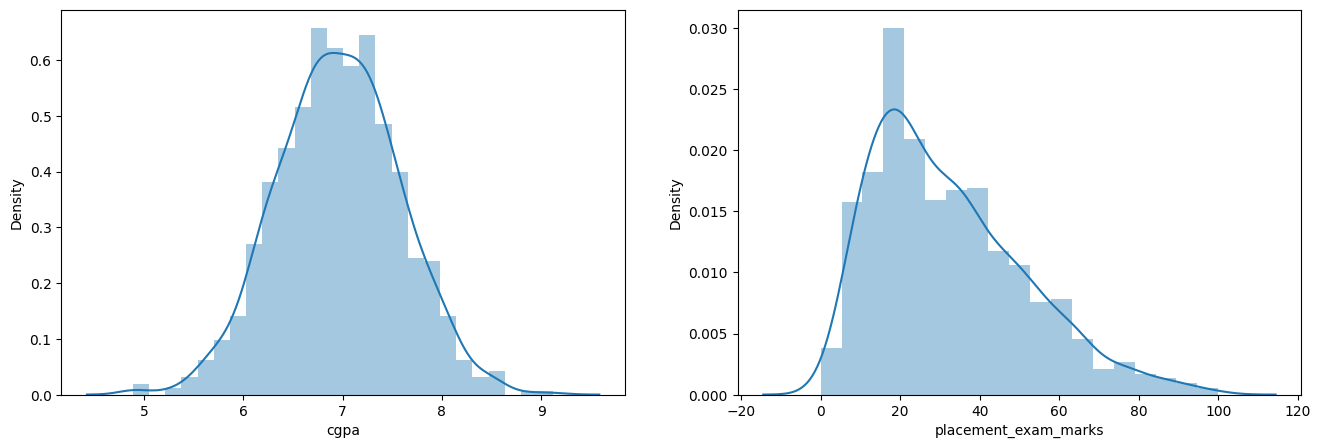

In [7]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['cgpa'])

plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])

plt.show()

* we perform IQR method on placement_exam_marks because it is skewed dataset 

In [8]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


<Axes: ylabel='placement_exam_marks'>

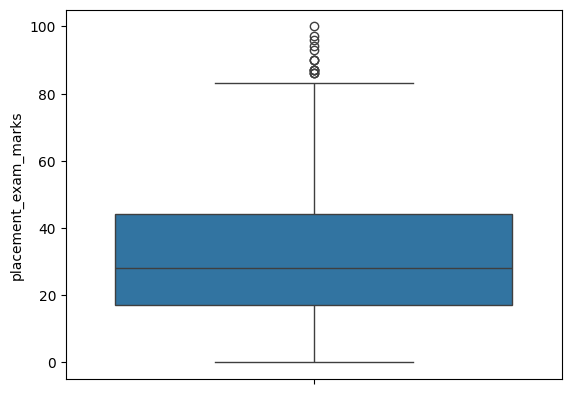

In [10]:
sns.boxplot(df['placement_exam_marks'])

#### IQR Outlier method formula 
* Max Range = Q3 + 1.5 * IQR
* Min Range = Q1 - 1.5 * IQR
* IQR = Q3(75 percentile) - Q1(25 percentile)

In [11]:
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
iqr = percentile75 - percentile25


In [12]:
iqr

np.float64(27.0)

In [14]:
# deafining the limits 
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
print(lower_limit)
print(upper_limit)


-23.5
84.5


In [27]:
# finding the values that are above the upper limit 
df[df['placement_exam_marks'] > upper_limit]
df[df['placement_exam_marks'] > upper_limit].count()

cgpa                    15
placement_exam_marks    15
placed                  15
dtype: int64

In [17]:
# finding the values that are below the limit limit 
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


#### Approach 1 Trimming

In [18]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [23]:
new_df.shape

(985, 3)

<Axes: ylabel='placement_exam_marks'>

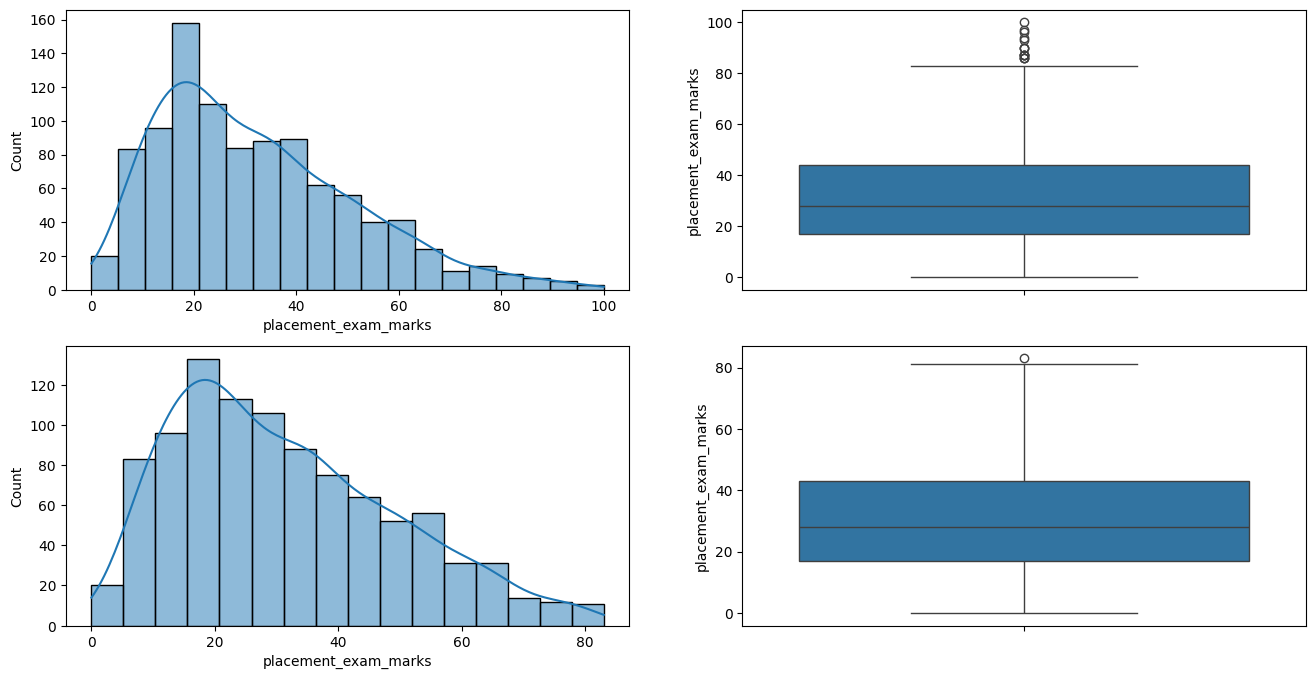

In [30]:
# Comparing the both data sets after removing outliers 

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

#### Approach 2 Cappping

In [33]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [34]:
new_df_cap.shape

(1000, 3)

<Axes: ylabel='placement_exam_marks'>

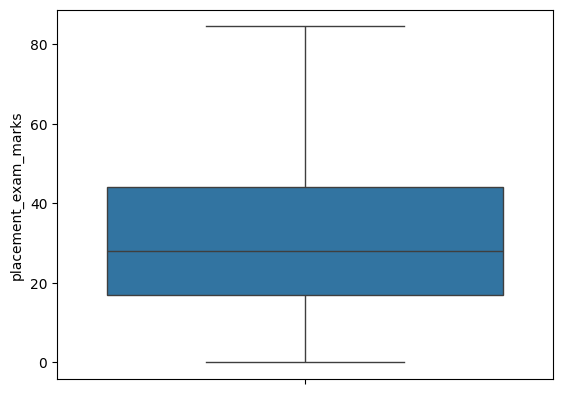

In [35]:
sns.boxplot(new_df_cap['placement_exam_marks'])